###  선형 회귀
- 문제 해결을 위해 가장 먼저 해야 할 일: 충분한 향의 입력 데이터와 타깃 데이터를 준비(ex. 당뇨병 데이터)

### 선형 회귀와 경사 하강법의 관계
- 선형회귀의 목표: 입력 데이터 x와 타깃 데이터 y를 통해 기울기($\alpha$)와 절편($\beta$)을 구하는 것
- 경사 하강법: 모델이 데이터를 잘 표현할 수 있도록 기울기(변화율)을 사용하여 모델을 조금씩 조정하는 최적화 알고리즘

### 예측값과 변화율
- 예측값: 모델을 통해 예측한 값(ex. $y=7x+4$에서 $x=2$일 때 예측값은 $y=18$)
- 변화율: 모델의 가중치와 절편을 효율적으로 업데이트시키기 위한 값  
    가중치를 키우고 싶을 때 가중치에 변화율을 더해주면 됨.  
    $\Delta w > 0, \hat y|_{x=w+\Delta w}$  는 증가  
    $\Delta w < 0, \hat y|_{x=w+\Delta w}$  는 증가

In [18]:
from sklearn.datasets import load_diabetes # 기본적으로 제공되는 연습용 당뇨병(diabetes) 데이터

diabetes = load_diabetes()
print(diabetes.data.shape, diabetes.target.shape) # (442, 10) (442,) : 샘플이 442개, 특성이 10개
print(diabetes.DESCR)

(442, 10) (442,)
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature v

In [2]:
diabetes.data[0:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [3]:
diabetes.target[:3]

array([151.,  75., 141.])

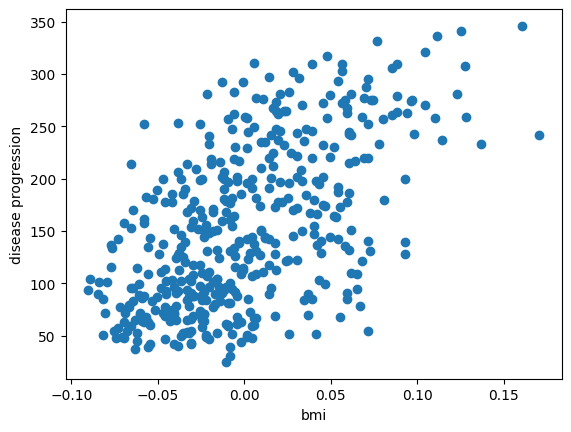

In [4]:
import matplotlib.pyplot as plt

plt.scatter(diabetes.data[:, 2], diabetes.target) # 모든 환자에 대해 2번 인덱스(bmi) 요소의 산점도를 그림.
# target( y축)의 숫자가 높을수록 질병이 더 진행됨(diabetes.DESCR의 :Target: Column 11 is a quantitative measure of disease progression one year after baseline 내용)
plt.xlabel('bmi')
plt.ylabel('disease progression')
plt.show()

In [29]:
from sklearn import datasets
import matplotlib.pyplot as plt

diabetes = datasets.load_diabetes()

w = 1.0
b = 1.0

x = diabetes.data[:,2]
y = diabetes.target

y_hat = x[0] * w + b
w_inc = w + 0.1
y_hat_inc = x[0] * w_inc + b
print(y_hat_inc)

w_rate = (y_hat_inc - y_hat) / (w_inc - w)
print(w_rate, x[0])
w_new = w + w_rate
print(w_new)

b_inc = b + 0.1
y_hat_inc = x[0]*w + b_inc
print(y_hat_inc)

b_rate = (y_hat_inc - y_hat) / (b_inc - b)
print(b_rate, 1.0)

print("업데이트 시작")

err = y[0] - y_hat # 실제값 y[0] 와 w, b 로 예측한 예측값 y_hat 의 오차 계산
w_new = w + w_rate * err # w_new = w + x[0] * err 와 같다.
b_new = b + 1 * err
print(w_new, b_new)

1.0678658271705517
0.06169620651868429 0.061696206518683294
1.0616962065186843
1.1616962065186833
1.0 1.0
업데이트 시작
10.250624555903848 150.9383037934813


아래 공식에 의해 가중치 변화율 = x[0], 절편 변화율 = 1이 됨.

$w\_rate = \frac{\hat y_{inc} - \hat y}{w_{inc} - w} = \frac{x[0] \times w_{inc} + b - (x[0] \times w + b)}{w_{inc} - w} = \frac{x[0] \times [(w + 0.1) - w]}{(w + 0.1) - w} = x[0]$  
$b\_rate = \frac{\hat y_{inc} - \hat y}{b_{inc} - b} = \frac{x[0] \times w + b_{inc} - (x[0] \times w + b)}{b_{inc} - b} = \frac{(b + 0.1) - b}{(b + 0.1) - b} = 1$

calculated: 587.8654539985616 99.4093556453094


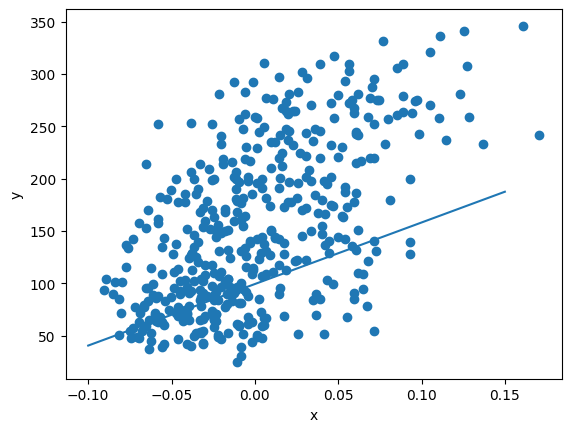

In [34]:
# 위의 내용을 종합하여 모든 타겟에 대해 조정 시작

from sklearn import datasets
import matplotlib.pyplot as plt

diabetes = datasets.load_diabetes()

x = diabetes.data[:,2]
y = diabetes.target

w = 1.0
b = 1.0

for x_i, y_i in zip(x, y):
    y_hat = x_i * w + b
    err = y_i - y_hat
    w += x_i * err
    b += err

print('calculated:', w, b)

plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

위의 코드 처럼 모든 샘플에 가중치, 절폅 업데이트를 한번 진행한 것을 **1 에포크(epoch)**동안 훈련시켰다 라고 한다.

100 에포크 동안 훈련시킨다면 더 정확해진다! *(아래 코드 확인)*

calculated: 913.5973364346786 123.39414383177173
287.8416643900139


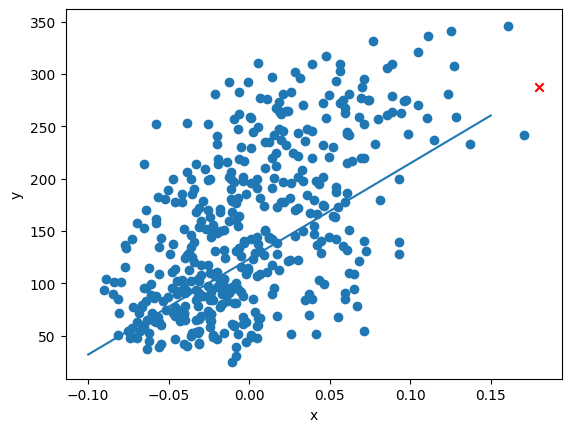

In [50]:
from sklearn import datasets
import matplotlib.pyplot as plt

diabetes = datasets.load_diabetes()

x = diabetes.data[:,2]
y = diabetes.target

w = 1.0
b = 1.0

for _ in range(100):
    for x_i, y_i in zip(x, y):
            y_hat = x_i * w + b
            err = y_i - y_hat
            w += x_i * err
            b += err

print('calculated:', w, b)

plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])
plt.xlabel('x')
plt.ylabel('y')


# 예측
x_new = 0.18
y_pred = x_new * w + b
print(y_pred)

plt.scatter(x_new, y_pred, color='red', marker='x')

plt.show()